# 📄 LLM-Based Workflows - Invoice Processing with Conditional Notifications

**Author:** *José Ignacio Orlando, PhD*

In this enhanced example, we're going to extend our invoice processing workflow with conditional edges to handle high-value invoices that require special approval processes. This demonstrates how LangGraph can orchestrate complex business logic with branching workflows.

Our goal is to create an automated system that can:
- Extract text from PDF invoices
- Use LLMs to parse and structure the invoice data
- Normalize and validate the extracted information
- **Conditionally route high-value invoices** (above $200,000) for CFO approval
- Generate email notifications for the financial department
- Export the results to CSV for further analysis

This workflow showcases the power of combining LangGraph's orchestration capabilities with conditional logic, creating a robust solution for document processing tasks that includes business rule enforcement.


## Step 1 - Environment Setup

Before we can start processing invoices, we need to set up our environment properly. This involves:

1. **Loading environment variables**: We use `python-dotenv` to securely load our OpenAI API key from a `.env` file
2. **API key validation**: We ensure the required API key is present before proceeding
3. **Model configuration**: We set up the OpenAI model we'll use for structured data extraction

The `load_dotenv()` function reads the `.env` file in your project directory, where you should store your OpenAI API key as `OPENAI_API_KEY=your_key_here`. This is a security best practice that prevents accidentally committing API keys to version control.

**Important**: Always remember to **not include .env files in your repository**. They should be part of your `.gitignore` file to prevent leaking your API keys online.


In [2]:
# to read environment variables from the system
from os import getenv
# to load environment variables from .env file
from dotenv import load_dotenv

# load the environment variables from .env file in the project directory
load_dotenv()
# validate that the OpenAI API key is present; raise an error if not found
assert getenv("OPENAI_API_KEY") is not None, "Please set OPENAI_API_KEY in .env or environment."

# get the model name from environment variable, defaulting to "gpt-5" if not set
OPENAI_MODEL = getenv("OPENAI_MODEL", "gpt-5")


## Step 2 - Define Data Models

Now we need to define the structure of our invoice data using Pydantic models. This is crucial for ensuring data consistency and validation throughout our pipeline.

We define three main models:
- **`LineItem`**: Represents individual items on an invoice with description, quantity, unit price, and total
- **`InvoiceSchema`**: The complete invoice structure including supplier information, dates, totals, and line items
- **`NotificationSchema`**: A new model for storing email notification data for high-value invoices

Using Pydantic models provides several benefits:
- **Type safety**: Ensures our data has the correct types
- **Validation**: Automatically validates data as it flows through the pipeline
- **Documentation**: The models serve as clear documentation of our data structure
- **LLM integration**: Works seamlessly with LangChain's structured output features

Notice how we use optional fields (`str | None`) for information that might not always be present in invoices, and we include field validators to ensure data quality.


In [3]:
# List type hint for collections
from typing import List
# pydantic components for data modeling and validation
from pydantic import BaseModel, Field, field_validator

# define a Pydantic model for individual invoice line items
class LineItem(BaseModel):
    description: str = Field(description="item description")     # item name or description
    quantity: float = Field(description="quantity purchased")    # number of units (float to allow decimals)
    unit_price: float = Field(description="price per unit")      # cost per unit
    total: float = Field(description="line item total")          # total cost for this line item
    
# define the main invoice schema using Pydantic for structured output
class InvoiceSchema(BaseModel):
    invoice_number: str  # invoice identifier (e.g., INV-2024-001)
    invoice_date: str    # date will be normalized later to YYYY-MM-DD when possible
    supplier_name: str   # company or person issuing the invoice
    
    # optional fields using union type (str | None) to indicate they may be missing
    supplier_address: str | None = None       # optional: address of the supplier
    supplier_vat: str | None = None           # optional: VAT/tax ID of the supplier
    customer_name: str | None = None          # optional: customer/buyer name
    customer_address: str | None = None       # optional: customer's address
    currency: str | None = Field(default=None, description="ISO 4217 (e.g., USD, EUR, ARS)")
    subtotal: float | None = None             # optional: pre-tax total amount
    tax: float | None = None                  # optional: tax amount

    total: float                              # final total amount
    line_items: List[LineItem]                # list of individual items purchased

    # custom validator to ensure invoice_date is not empty
    @field_validator("invoice_date")
    @classmethod
    def nonempty(cls, v):
        # check if the date string is empty or whitespace-only
        if not v or not v.strip():
            raise ValueError("invoice_date required")
        return v

# define schema for email notifications generated for high-value invoices
class NotificationSchema(BaseModel):
    """Schema for high-value invoice notifications to the financial department."""
    subject: str = Field(description="Email subject line")              # email subject
    recipient: str = Field(description="Email recipient (financial department)")  # who receives it
    body: str = Field(description="Email body content")                 # email content
    priority: str = Field(description="Priority level (HIGH, URGENT, etc.)")     # how urgent it is
    requires_approval: bool = Field(description="Whether CFO approval is required")  # approval flag


## Step 3 - Define the Enhanced Graph State

As in all our LangGraph examples, we need to define the state that will flow through our processing pipeline. The `GraphState` serves as our shared memory, allowing different nodes to access and update information as the invoice is processed.

Our enhanced state tracks the complete processing pipeline including the new notification workflow:
- **`pdf_path`**: The input PDF file path
- **`raw_text`**: Extracted text from the PDF
- **`extracted`**: Structured data extracted by the LLM
- **`normalized`**: Cleaned and validated invoice data
- **`notification`**: Email notification data for high-value invoices (new!)
- **`csv_path`**: Output CSV file path

This state design allows us to track the invoice through each processing stage, including the conditional notification path, making it easy to debug issues and understand the complete data transformation pipeline.


In [4]:
# to create a type-safe dictionary for our graph state
from typing import TypedDict

# define the state structure that flows through our LangGraph workflow
# TypedDict ensures type safety and autocompletion for state fields
class GraphState(TypedDict):
    pdf_path: str                           # input PDF file path (required)
    raw_text: str | None                    # extracted text from PDF (populated by load_pdf node)
    extracted: InvoiceSchema | None         # structured invoice data from LLM extraction
    normalized: InvoiceSchema | None        # cleaned and normalized invoice data
    notification: NotificationSchema | None # new field for high-value invoice notifications
    csv_path: str | None                    # output CSV file path (where results are written)


## Step 4 - Set up the LLMs for Structured Output

Here we configure our LLMs to return structured data that matches our Pydantic models. This is a powerful feature that allows us to get consistent, validated data from the LLMs.

Doing two tasks with a single model is pointless: it might confuse the LLM and eventually damage the reliability of the tool. So, in order to achieve a good solution, let's create two instances of the LLM:
- **`structured_llm`**: For invoice data extraction (returns `InvoiceSchema`)
- **`notification_llm`**: For generating email notifications (returns `NotificationSchema`)

The key components are:
- **`ChatOpenAI`**: Our interface to OpenAI's models, as we were using before
- **`with_structured_output()`**: This method configures the LLM to return data in our specified schema format, as we did in the previous example.

Under the hood, LangChain uses function calling (tool calling) to ensure the LLM returns data in the exact format we need. This eliminates the need for manual parsing and validation of LLM responses, making our pipeline much more reliable.


In [5]:
# for interfacing with OpenAI's chat models
from langchain_openai import ChatOpenAI

# create the base LLM instance using the model from environment variables
llm = ChatOpenAI(model=OPENAI_MODEL)

# wrap the LLM to return structured data parsed into our Pydantic models
# LangChain's with_structured_output uses tool/function-calling under the hood
# this ensures the LLM returns data in the exact format we specify
structured_llm = llm.with_structured_output(InvoiceSchema)        # for extracting invoice data
notification_llm = llm.with_structured_output(NotificationSchema) # for generating email notifications


## Step 5 - PDF Text Extraction

Our first processing node handles the extraction of text from PDF files. This is a critical step because the quality of our extraction directly impacts the accuracy of our LLM-based parsing.

The `load_pdf` function:
- Opens the PDF file using `pdfplumber`
- Extracts text from each page
- Combines all text into a single string
- Stores the result in our graph state

**Note**: This implementation works with text-based PDFs. For scanned PDFs, you would need to add OCR (Optical Character Recognition) upstream to convert images to text first.

The extracted text will serve as input to our LLM, so it's important that it's clean and complete.


In [6]:
# for PDF text extraction
import pdfplumber

# node 1: load & extract text from PDF (text PDFs; add OCR upstream for scanned PDFs)
def load_pdf(state: GraphState) -> GraphState:
    # get the PDF file path from the state
    pdf_path = state["pdf_path"]
    # initialize a list to store text from each page
    text_chunks = []
    
    # open the PDF file using pdfplumber
    with pdfplumber.open(pdf_path) as pdf:
        # iterate through each page in the PDF
        for page in pdf.pages:
            # extract text from the current page, defaulting to empty string if extraction fails
            text = page.extract_text() or ""
            # append the extracted text to our list
            text_chunks.append(text)
    
    # join all page texts with newlines, strip whitespace, and store in state
    state["raw_text"] = "\n".join(text_chunks).strip()
    return state


## Step 6 - LLM-Based Data Extraction

Our `extract_with_llm` node uses the power of LLMs to intelligently parse the raw invoice text and extract structured data.

The process involves:
1. **System prompt**: We provide clear instructions about the extraction task
2. **User prompt**: We pass the raw invoice text to the LLM
3. **Structured output**: The LLM returns data in our exact `InvoiceSchema` format
4. **State update**: We store the extracted data in our graph state

The LLM is particularly good at this task because it can:
- Understand different invoice formats and layouts
- Handle variations in terminology and formatting
- Extract information even when it's not perfectly structured
- Make intelligent guesses about missing information

This demonstrates the power of combining traditional data processing with AI capabilities.


In [7]:
# node 2: LLM extraction (ChatOpenAI + structured output)
def extract_with_llm(state: GraphState) -> GraphState:
    # get the raw extracted text from the state, defaulting to empty string if missing
    raw = state.get("raw_text") or ""
    
    # define the system prompt that instructs the LLM on how to extract invoice data
    system_prompt = (
        "You are an expert data extractor for invoices. "
        "Given raw invoice text, produce a structured object that adheres to the provided schema. "
        "If a value is missing, omit it or use null when allowed. Do not fabricate fields."
    )
    
    # create the user message with the invoice text
    user = f"Invoice text:\n\n{raw}\n\nReturn only the structured object."

    # LangChain accepts lists of messages or strings; we'll use messages for clarity
    # call the structured LLM with system and user messages
    result: InvoiceSchema = structured_llm.invoke(
        [
            {"role": "system", "content": system_prompt},  # system message with instructions
            {"role": "user", "content": user},             # user message with invoice text
        ]
    )
    
    # store the extracted and validated invoice data in the state
    state["extracted"] = result
    return state


## Step 7 - Data Normalization and Validation

After extracting the raw data, we need to clean and normalize it to ensure consistency. The `normalize` function handles several important tasks:

- **Date normalization**: Converts various date formats to ISO standard (YYYY-MM-DD)
- **Currency handling**: Sets default currency if none is specified
- **Data validation**: Ensures all required fields are present
- **Format consistency**: Standardizes data formats across different invoices

The normalization process includes intelligent date parsing that can handle common formats like DD/MM/YYYY and MM/DD/YYYY, automatically converting them to the ISO standard.

This step is crucial for downstream processing and analysis, as it ensures all our invoice data follows consistent formats and standards.


In [8]:
# for regex pattern matching
import re
# dataclass decorator for creating configuration class
from dataclasses import dataclass

# node 3: normalize & light validation
# define a configuration class for normalization settings
@dataclass
class NormalizationConfig:
    default_currency: str = "USD"  # default currency when none is specified

# helper function to convert dates to ISO format (YYYY-MM-DD)
def _guess_date_iso(d: str) -> str:
    # remove leading/trailing whitespace
    d = d.strip()
    
    # already ISO format - no conversion needed
    if re.match(r"^\d{4}-\d{2}-\d{2}$", d):
        return d
    
    # try to match DD/MM/YYYY or MM/DD/YYYY with various separators
    # assume format is D/M/Y and reorder to YYYY-MM-DD
    m = re.match(r"^(\d{1,2})[./-](\d{1,2})[./-](\d{4})$", d)
    if m:
        # extract day, month, and year components
        a, b, y = m.groups()
        day, month = int(a), int(b)
        # format as YYYY-MM-DD with zero-padding for month/day
        return f"{y}-{month:02d}-{day:02d}"
    
    # if format is unknown, return unchanged
    return d

# main normalization function that cleans and validates invoice data
def normalize(state: GraphState, cfg: NormalizationConfig = NormalizationConfig()) -> GraphState:
    # get the extracted invoice data from state
    inv: InvoiceSchema = state["extracted"]
    
    # use the invoice currency or default to USD if not specified
    currency = inv.currency or cfg.default_currency
    
    # convert the date to ISO format
    date_iso = _guess_date_iso(inv.invoice_date)

    # create a new normalized InvoiceSchema with cleaned data
    normalized = InvoiceSchema(
        invoice_number=inv.invoice_number,       # keep the invoice number as-is
        invoice_date=date_iso,                   # use the ISO-formatted date
        supplier_name=inv.supplier_name,
        supplier_address=inv.supplier_address,
        supplier_vat=inv.supplier_vat,
        customer_name=inv.customer_name,
        customer_address=inv.customer_address,
        currency=currency,                       # use normalized currency
        subtotal=inv.subtotal,
        tax=inv.tax,
        total=inv.total,
        line_items=inv.line_items,
    )
    
    # store the normalized data back in the state
    state["normalized"] = normalized
    return state


## Step 8 - High-Value Invoice Notification

This is our new conditional node that generates email notifications for high-value invoices. This node demonstrates how LLMs can be used to create professional, contextual communications for business processes.

The `generate_notification` function:
- **Analyzes the invoice**: Extracts key information about the high-value invoice
- **Generates professional email**: Uses the LLM to create a well-structured notification
- **Includes business context**: Explains why CFO approval is needed
- **Stores notification data**: Saves the email content in our graph state

The LLM is particularly effective here because it can:
- Write professional business communications
- Adapt the tone and content based on invoice details
- Include relevant financial information and context
- Generate consistent, well-structured emails

This showcases how LLMs can automate not just data extraction, but also business communication workflows.


In [9]:
# Node 4: Generate notification for high-value invoices
def generate_notification(state: GraphState) -> GraphState:
    """Generate email notification for high-value invoices requiring CFO approval."""
    # get the normalized invoice data from the state
    invoice = state["normalized"]
    
    # define the system prompt that instructs the LLM on how to write the email
    system_prompt = (
        "You are a financial assistant writing professional emails for the financial department. "
        "Generate a clear, professional email notification about a high-value invoice that requires CFO approval. "
        "Include relevant details about the invoice, supplier, amount, and why approval is needed."
    )
    
    # create a detailed user prompt with invoice information
    user_prompt = f"""
    Please generate an email notification for the following high-value invoice:
    
    Invoice Number: {invoice.invoice_number}
    Invoice Date: {invoice.invoice_date}
    Supplier: {invoice.supplier_name}
    Total Amount: {invoice.currency} {invoice.total:,.2f}
    Supplier Address: {invoice.supplier_address or 'Not provided'}
    Supplier VAT: {invoice.supplier_vat or 'Not provided'}
    
    This invoice exceeds our $200,000 threshold and requires CFO approval before payment.
    
    Generate a professional email that:
    1. Clearly states the purpose (high-value invoice requiring approval)
    2. Summarizes key invoice details
    3. Explains why CFO approval is needed
    4. Includes next steps for the approval process
    """
    
    # invoke the LLM to generate the notification email
    result: NotificationSchema = notification_llm.invoke([
        {"role": "system", "content": system_prompt},  # system instructions
        {"role": "user", "content": user_prompt}       # invoice details
    ])
    
    # store the generated notification in the state
    state["notification"] = result
    return state


## Step 9 - Conditional Routing Logic

This is the heart of our conditional workflow! The `route_by_value` function examines the invoice total and decides whether to generate a notification for CFO approval or proceed directly to CSV export.

Our business rule is simple:
- **Invoices ≤ $200,000**: Process normally and export to CSV
- **Invoices > $200,000**: Generate notification for CFO approval, then export to CSV

The conditional node returns a `Literal` type that tells LangGraph which path to follow:
- `"generate_notification"`: For high-value invoices requiring approval
- `"write_csv"`: For standard invoices that can be processed directly

This demonstrates how LangGraph can implement complex business logic with simple, readable conditional functions.


In [10]:
# for type-safe string constants
from typing import Literal

# conditional routing function - determines the workflow path based on invoice value
def route_by_value(state: GraphState) -> Literal["generate_notification", "write_csv"]:
    """route based on invoice total value."""
    # get the normalized invoice data from the state
    invoice = state["normalized"]
    
    # define the threshold for high-value invoices requiring CFO approval
    high_value_threshold = 200000.0
    
    # check if the invoice total exceeds the threshold
    if invoice.total > high_value_threshold:
        # route to notification generation for high-value invoices
        return "generate_notification"
    else:
        # Route directly to CSV export for standard invoices
        return "write_csv"


## Step 10 - CSV Export

The final step in our pipeline exports the processed invoice data to a CSV file. This makes the data accessible for further analysis, reporting, or integration with other systems. Think of this as a SQL INSERT on a database.

The `write_csv` function:
- **Creates headers**: Defines the CSV column structure
- **Handles first write**: Creates the file with headers if it doesn't exist
- **Appends data**: Adds new invoice records to existing files
- **JSON serialization**: Stores line items as JSON strings for complex data
- **Includes notification flag**: Adds a field to indicate if notification was generated

The CSV format is particularly useful because:
- It's widely supported by spreadsheet applications
- It's easy to import into databases
- It's human-readable for manual inspection
- It supports incremental updates (appending new invoices)
- It can track which invoices required special approval

This completes our invoice processing pipeline, transforming unstructured PDF data into structured, analyzable information with business rule enforcement.


In [11]:
# for CSV file operations
import csv
# for file path operations
from os import path

# node 5: write/append to CSV (flat header + items JSON column + notification flag)
# define the CSV column headers including all invoice fields and notification data
CSV_HEADERS = [
    "invoice_number","invoice_date","supplier_name","supplier_address","supplier_vat",
    "customer_name","customer_address","currency","subtotal","tax","total","line_items_json",
    "requires_approval","notification_subject","notification_body"
]

def write_csv(state: GraphState) -> GraphState:
    # get the normalized invoice data from the state
    inv: InvoiceSchema = state["normalized"]
    # get the CSV file path from state, defaulting to "invoices.csv"
    csv_path = state.get("csv_path") or "invoices.csv"
    # check if this is the first write to the file (for header writing)
    first_write = not path.exists(csv_path)
    
    # check if notification was generated for this invoice
    notification = state.get("notification")
    requires_approval = notification is not None  # true if notification exists
    notification_subject = notification.subject if notification else ""  # get subject or empty string
    notification_body = notification.body if notification else ""        # get body or empty string

    # build the CSV row with all invoice data
    row = {
        "invoice_number": inv.invoice_number,                          # invoice ID
        "invoice_date": inv.invoice_date,                              # invoice date
        "supplier_name": inv.supplier_name,                           # supplier name
        "supplier_address": inv.supplier_address or "",               # Supplier address (default to empty)
        "supplier_vat": inv.supplier_vat or "",                       # Supplier VAT ID (default to empty)
        "customer_name": inv.customer_name or "",                    # customer name (default to empty)
        "customer_address": inv.customer_address or "",              # customer address (default to empty)
        "currency": inv.currency or "",                              # currency code (default to empty)
        "subtotal": inv.subtotal if inv.subtotal is not None else "", # subtotal (or empty string)
        "tax": inv.tax if inv.tax is not None else "",              # tax amount (or empty string)
        "total": inv.total,                                          # total amount
        "line_items_json": [li.model_dump() for li in inv.line_items], # convert line items to dicts
        "requires_approval": requires_approval,                       # approval flag
        "notification_subject": notification_subject,                 # notification subject
        "notification_body": notification_body,                       # notification body
    }

    # open the CSV file in append mode with UTF-8 encoding
    with open(csv_path, "a", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=CSV_HEADERS)
        if first_write:
            # write the CSV header row on first write
            writer.writeheader()
        # write the data row, converting line_items_json to string
        writer.writerow({**row, "line_items_json": str(row["line_items_json"])})

    # update the state with the CSV path
    state["csv_path"] = csv_path
    return state


## Step 11 - Build the Conditional LangGraph Workflow

Now we put everything together to create our complete conditional invoice processing workflow. This is where LangGraph's orchestration capabilities shine, managing the flow of data through our processing pipeline with intelligent routing.

Our workflow follows this structure:
1. **START** → `load_pdf` (extract text from PDF)
2. `load_pdf` → `extract_with_llm` (parse with LLM)
3. `extract_with_llm` → `normalize` (clean and validate data)
4. `normalize` → **CONDITIONAL ROUTING** (based on invoice value)
   - **If ≤ $200,000**: `normalize` → `write_csv` → **END**
   - **If > $200,000**: `normalize` → `generate_notification` → `write_csv` → **END**

The key differences from our previous sequential graph are:
- **Conditional edges**: We use `add_conditional_edges()` to create branching logic
- **Multiple paths**: High-value invoices take a different path through the notification node
- **Business rule enforcement**: The graph automatically enforces our $200,000 threshold

Each node in our graph has a specific responsibility, and the state flows through them based on the conditional logic. This design makes it easy to:
- Debug individual steps
- Add new processing stages
- Handle errors at specific points
- Monitor the processing pipeline
- Enforce business rules automatically

The `compile()` method finalizes our workflow and makes it ready for execution.


In [12]:
# import StateGraph for building the workflow graph
from langgraph.graph import StateGraph, START, END
# import RunnableConfig for configuring graph execution
from langchain_core.runnables import RunnableConfig

# build the conditional workflow using StateGraph with our GraphState type
workflow = StateGraph(GraphState)

# register all processing nodes with the workflow
workflow.add_node("load_pdf", load_pdf)                           # extract text from PDF
workflow.add_node("extract_with_llm", extract_with_llm)           # parse invoice with LLM
workflow.add_node("normalize", normalize)                         # clean and validate data
workflow.add_node("generate_notification", generate_notification) # generate email for high-value invoices
workflow.add_node("write_csv", write_csv)                         # export to CSV

# linear chain: START → load_pdf → extract_with_llm → normalize
# define the initial sequential flow of the pipeline
workflow.add_edge(START, "load_pdf")                             # start with PDF loading
workflow.add_edge("load_pdf", "extract_with_llm")                # then extract data
workflow.add_edge("extract_with_llm", "normalize")               # then normalize

# conditional routing from normalize based on invoice value
# This is where the workflow branches based on the invoice total
workflow.add_conditional_edges(
    "normalize",                  # source node: normalized invoice data
    route_by_value,               # conditional function that decides the path
    {
        "generate_notification": "generate_notification",  # path for high-value invoices (> $200k)
        "write_csv": "write_csv",                          # path for standard invoices (≤ $200k)
    },
)

# both paths lead to CSV export and then END
# high-value invoices: normalize → generate_notification → write_csv → END
workflow.add_edge("generate_notification", "write_csv")
# standard invoices: normalize → write_csv → END
workflow.add_edge("write_csv", END)

# compile the workflow to make it ready for execution
app = workflow.compile()


Let's visualize our conditional workflow to see how the branching logic works:


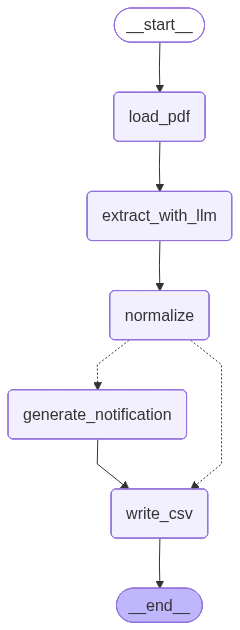

In [13]:
# Import Image and display for visualizing the graph
from IPython.display import Image, display

# Visualize the conditional graph by generating a Mermaid diagram and displaying it
# The graph shows the branching logic: how high-value invoices take a different path
display(Image(app.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))


To ease the execution, we're gonna implement an auxiliary function that will take the PDF path of an invoice and a CSV path, and will create the graph state and execute the graph once.


In [17]:
def run_once(pdf_path: str, csv_path: str = "invoices.csv"):
    """Process a single invoice through the conditional workflow."""
    # initialize the graph state with all fields set to None except the input path
    state: GraphState = {
        "pdf_path": pdf_path,      # input PDF file path
        "raw_text": None,           # will be populated by load_pdf
        "extracted": None,          # Will be populated by extract_with_llm
        "normalized": None,         # Will be populated by normalize
        "notification": None,      # Will be populated by generate_notification for high-value invoices
        "csv_path": csv_path,       # Output CSV file path
    }
    
    # execute the workflow with the initial state
    result = app.invoke(state, config=RunnableConfig(run_name="invoice_to_csv_with_notification"))
    
    # get the normalized invoice data from the result
    invoice = result["normalized"]
    # get the notification if it was generated (None for standard invoices)
    notification = result.get("notification")
    
    # print processing results
    print(f"✅ Processed invoice: {invoice.invoice_number}")
    print(f"💰 Total: {invoice.currency} {invoice.total:,.2f}")
    
    # check if a notification was generated (high-value invoice)
    if notification:
        print(f"📧 notification generated: {notification.subject}")
        print(f"📧 email body: {notification.body}")
        print(f"🔔 requires CFO approval: {notification.requires_approval}")
    else:
        print("✅ Standard processing - no approval required")
    
    # print where the results were saved
    print(f"📄 appended to: {result['csv_path']}")
    return result


## Step 12 - Test with Sample Invoices

Let's test our conditional pipeline with sample invoices to see how it handles both standard and high-value invoices. This will demonstrate the branching logic in action.

**What we'll test:**
1. **Standard invoice** (≤ $200,000): Should process normally without notification
2. **High-value invoice** (> $200,000): Should generate notification for CFO approval

**What just happened?**
Our conditional pipeline successfully:
1. Extracted text from the PDF invoice
2. Used the LLM to parse and structure the data
3. Normalized the extracted information
4. **Applied business rules** based on invoice value
5. **Conditionally generated notifications** for high-value invoices
6. Exported the results to CSV with approval tracking

The processing completed successfully, and we can see how the conditional logic routes different types of invoices through appropriate approval workflows.


In [ ]:
# test with a standard invoice (should not trigger notification)
print("=== testing standard invoice ===")
pdf_example = "./samples/demo-invoice-20tax-1.pdf"  # sample invoice file
# process the invoice through the workflow
result = run_once(pdf_example, "invoices_with_notifications.csv")

=== testing standard invoice ===
✅ Processed invoice: 86864
💰 Total: USD 1,287.40
✅ Standard processing - no approval required
📄 appended to: invoices_with_notifications.csv


=== testing high-value invoice (simulated) ===
✅ Processed invoice: 347003
💰 Total: USD 577,271.99
📧 notification generated: Action required: CFO approval needed — Invoice 347003 (USD 577,271.99) from Contoso Asia
🔔 requires CFO approval: True
📄 appended to: invoices_with_notifications.csv


In [18]:
# test with a high-value invoice (should trigger notification)
print("=== testing high-value invoice (simulated) ===")
pdf_example = "./samples/demo-invoice-20tax-2.pdf"  # sample invoice file
# process the invoice through the workflow
result = run_once(pdf_example, "invoices_with_notifications.csv")


=== testing high-value invoice (simulated) ===
✅ Processed invoice: 347003
💰 Total: USD 577,271.99
📧 notification generated: CFO Approval Required: High-Value Invoice 347003 – Contoso Asia (USD 577,271.99)
📧 email body: Dear CFO and AP Team,

Purpose: This is a high-value invoice notification requiring CFO approval prior to payment.

Key invoice details:
- Supplier: Contoso Asia (VAT: CN213 4444 66)
- Supplier Address: 123 Xia Street, Beijing, 100027
- Invoice Number: 347003
- Invoice Date: 29 Mar 2025
- Total Amount: USD 577,271.99

Reason for approval: The invoice total exceeds our $200,000 authorization threshold; therefore, CFO approval is required before the invoice can be scheduled for payment in accordance with our payment authorization policy.

Next steps:
1) Please review the attached invoice and supporting documentation.
2) Provide approval by either:
   - Approving in the AP approval workflow, or
   - Replying to this email with written approval from your company email accou